# BIG-DATA-GRUPO-4 - Notebook Oficial Multiplataforma (Local & Google Colab)

**MIA - Big Data - Universidad de Palermo - Grupo 4**

Este notebook ejecuta el pipeline completo de ingeniería de datos y analítica distribuida:
1. **Conversión optimizada de CSV a Parquet** con índices internos por bloque (Sorting geoespacial, compresión ZSTD, diccionario de strings y estadísticas min/max).
2. **Consultas 3, 4, 6, 8 y 10** con benchmark comparativo de rendimiento **Pandas vs PySpark**.
3. **Pipeline de Machine Learning** distribuido con **Spark MLlib** (clasificador DecisionTree para predicción de severidad vial).
4. **Análisis Exploratorio de Datos (EDA)** y visualizaciones estadísticas.

> **Compatibilidad:** Diseñado con detección dinámica de entorno para correr sin errores tanto en Google Colab como en entorno local (Windows / Linux / macOS).

In [1]:
# 1. Detección Inteligente del Entorno de Ejecución (Local vs Google Colab)
import sys
import os

EN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
print(f"[*] Entorno detectado: {'GOOGLE COLAB' if EN_COLAB else 'LOCAL / WORKSTATION'}")

if EN_COLAB:
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive/MyDrive'):
            print('[INFO] Conectando Google Drive (opcional)...')
            drive.mount('/content/drive')
        else:
            print('[OK] Google Drive ya se encuentra montado.')
    except Exception as e:
        print(f'[AVISO] Google Drive no fue montado ({e}). Se operará en disco local de Colab.')
else:
    print('[OK] Entorno local verificado. No se requiere montar Google Drive.')

[*] Entorno detectado: LOCAL / WORKSTATION
[OK] Entorno local verificado. No se requiere montar Google Drive.


In [2]:
# 2. Instalación Condicional de Dependencias
if EN_COLAB:
    print('[INFO] Instalando dependencias requeridas en Google Colab...')
    !pip install -q "pyspark>=3.5.0" "pandas>=2.0.0" "pyarrow>=14.0.0" "fastparquet>=2023.10.1" "matplotlib>=3.8.0" "seaborn>=0.13.0" "kaggle"
else:
    print('[OK] Entorno local: librerías gestionadas por el entorno virtual activo.')

print('Python versión: ' + sys.version.split()[0])

[OK] Entorno local: librerías gestionadas por el entorno virtual activo.
Python versión: 3.12.0


In [3]:
# 3. Configuración Multiplataforma de Java y Apache Spark
import os
import shutil
import subprocess

if EN_COLAB:
    if not shutil.which('java'):
        print('[INFO] Instalando OpenJDK 11 en Google Colab...')
        !apt-get update -qq && apt-get install -y -qq openjdk-11-jdk-headless
    
    # Detección dinámica de JAVA_HOME para evitar rutas hardcodeadas obsoletas
    if 'JAVA_HOME' not in os.environ or not os.path.exists(os.environ.get('JAVA_HOME', '')):
        for jvm_path in ['/usr/lib/jvm/java-17-openjdk-amd64', '/usr/lib/jvm/java-11-openjdk-amd64', '/usr/lib/jvm/default-java']:
            if os.path.exists(jvm_path):
                os.environ['JAVA_HOME'] = jvm_path
                print(f'[OK] JAVA_HOME configurado en: {jvm_path}')
                break
else:
    print(f"[OK] JAVA_HOME activo: {os.environ.get('JAVA_HOME', 'Configurado en PATH')}")

# Validación de instalación de Java
try:
    check_jvm = subprocess.run(['java', '-version'], capture_output=True, text=True)
    java_ver = (check_jvm.stderr or check_jvm.stdout).splitlines()[0]
    print(f'[OK] Motor Java operativo: {java_ver}')
except Exception as err:
    print(f'[WARN] No se pudo verificar Java: {err}')

[OK] JAVA_HOME activo: C:\Users\diego\jdk-17\jdk-17.0.10+7
[OK] Motor Java operativo: openjdk version "17.0.20.1" 2026-08-18 LTS


In [4]:
# 4. Sincronización de Directorio de Trabajo y Código Fuente (src)
import os
import sys

if EN_COLAB:
    repo = 'BIG-DATA-GRUPO-4'
    if not os.path.exists('src') and not os.path.exists(repo):
        print('[INFO] Clonando repositorio de GitHub en Colab...')
        !git clone https://github.com/jdiegoweber-debug/BIG-DATA-GRUPO-4.git
    
    if os.path.exists(repo) and not os.path.exists('src'):
        os.chdir(repo)
    print(f'[OK] Directorio de trabajo: {os.getcwd()}')
else:
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
    print(f'[OK] Directorio de trabajo local: {os.getcwd()}')

# Incorporar src al sys.path para importación modular limpia
src_path = os.path.abspath('src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print(f"[OK] Módulo 'src' registrado en sys.path: {src_path}")

[OK] Directorio de trabajo local: C:\Users\diego\excel_rtd\mmm\BIG-DATA-GRUPO-4
[OK] Módulo 'src' registrado en sys.path: C:\Users\diego\excel_rtd\mmm\BIG-DATA-GRUPO-4\src


In [5]:
# 5. Detección y Aprovisionamiento del Dataset (Parquet / CSV)
import shutil

parquet_path = os.path.join('data', 'raw', 'us_accidents.parquet')
csv_path = os.path.join('data', 'raw', 'us_accidents.csv')
os.makedirs(os.path.dirname(parquet_path), exist_ok=True)

if os.path.exists(parquet_path):
    print(f'[OK] Dataset Parquet listo: {parquet_path} ({os.path.getsize(parquet_path)/(1024**2):.2f} MB)')
elif os.path.exists(csv_path):
    print(f'[OK] Dataset CSV listo para convertir: {csv_path} ({os.path.getsize(csv_path)/(1024**3):.2f} GB)')
elif EN_COLAB:
    # Búsqueda en Google Drive
    encontrado = False
    for opcion in ['/content/drive/MyDrive/us_accidents.parquet', '/content/drive/MyDrive/us_accidents.csv']:
        if os.path.exists(opcion):
            destino = parquet_path if opcion.endswith('.parquet') else csv_path
            print(f'[INFO] Copiando dataset desde Drive: {opcion} -> {destino}...')
            shutil.copy2(opcion, destino)
            encontrado = True
            break
    if not encontrado:
        print('[AVISO] Dataset no encontrado en data/raw/ ni en Google Drive.')
        print('Ejecuta la celda siguiente para descargarlo desde Kaggle si es necesario.')
else:
    print('[AVISO] En entorno local, asegúrate de colocar el archivo en data/raw/.')

[OK] Dataset Parquet listo: data\raw\us_accidents.parquet (491.33 MB)


In [6]:
# 6. [OPCIONAL] Descarga de Kaggle (solo requerida si no existe ni el Parquet ni el CSV)
if not os.path.exists(parquet_path) and not os.path.exists(csv_path) and EN_COLAB:
    print('[INFO] Descarga desde Kaggle activada. Sube tu token kaggle.json:')
    try:
        from google.colab import files
        subidos = files.upload()
        if 'kaggle.json' in subidos:
            os.makedirs('/root/.kaggle', exist_ok=True)
            !cp kaggle.json /root/.kaggle/ && chmod 600 /root/.kaggle/kaggle.json
            !kaggle datasets download -d sobhanmoosavi/us-accidents -p data/raw --unzip
            print('[OK] Descarga de Kaggle finalizada.')
    except Exception as e:
        print(f'[ERROR] Error en descarga de Kaggle: {e}')
else:
    print('[OK] Dataset disponible en el sistema. Celda omitida.')

[OK] Dataset disponible en el sistema. Celda omitida.


In [7]:
# 7. Conversión de CSV a Parquet con Índices Físicos Internos
from convert_to_parquet import csv_to_parquet

if os.path.exists(parquet_path):
    print(f'[OK] Parquet optimizado ya existe: {parquet_path} ({os.path.getsize(parquet_path)/(1024**2):.2f} MB)')
elif os.path.exists(csv_path):
    print('[INFO] Parquet no encontrado. Ejecutando conversión e indexación física...')
    csv_to_parquet(csv_path=csv_path, parquet_path=parquet_path)
else:
    raise FileNotFoundError('No se encontró ni us_accidents.parquet ni us_accidents.csv en data/raw/')

[OK] Parquet optimizado ya existe: data\raw\us_accidents.parquet (491.33 MB)


In [8]:
# 8. EDA Inicial: Esquema Estructural y Muestra de Control
import pandas as pd

df_muestra = pd.read_parquet(parquet_path).head(5)
print('=== ESQUEMA ESTRUCTURAL DEL DATASET ===')
df_muestra.info()

print('\n=== PRIMERAS 5 FILAS ===')
try:
    from IPython.display import display
    display(df_muestra)
except ImportError:
    print(df_muestra)

=== ESQUEMA ESTRUCTURAL DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     5 non-null      string 
 1   Source                 5 non-null      string 
 2   Severity               5 non-null      int64  
 3   Start_Time             5 non-null      string 
 4   End_Time               5 non-null      string 
 5   Start_Lat              5 non-null      float64
 6   Start_Lng              5 non-null      float64
 7   End_Lat                0 non-null      float64
 8   End_Lng                0 non-null      float64
 9   Distance(mi)           5 non-null      float64
 10  Description            5 non-null      string 
 11  Street                 5 non-null      string 
 12  City                   5 non-null      string 
 13  County                 5 non-null      string 
 14  State                 

In [9]:
# 9. Consulta 3: Hotspots Espaciales - Distancia Haversine (Pandas vs PySpark)
from consulta_3 import ejecutar_pandas as c3_pandas, ejecutar_pyspark as c3_pyspark

print('=' * 60)
print('CONSULTA 3: Hotspots espaciales - Haversine R=25km (Los Angeles)')
print('=' * 60)

t_p = c3_pandas(parquet_path)
t_s = c3_pyspark(parquet_path)
speedup = t_p / max(t_s, 0.0001)
print(f'\n[SPEEDUP CONSULTA 3]: {speedup:.2f}x (Pandas vs PySpark)')

CONSULTA 3: Hotspots espaciales - Haversine R=25km (Los Angeles)

[START] [PANDAS] Ejecutando Consulta 3 (Haversine R=25.0 km)...
--- PRIMEROS 10 ACCIDENTES MAS CERCANOS ENCONTRADOS (PANDAS) ---
 Start_Lat   Start_Lng  Severity  Distancia_KM
 34.049621 -118.239820         2      0.045288
 34.050218 -118.240689         2      0.067949
 34.050370 -118.240880         2      0.090916
 34.050180 -118.241053         2      0.099056
 34.048885 -118.239189         2      0.144757
 34.049330 -118.241712         2      0.174438
 34.050257 -118.238061         2      0.180912
 34.051745 -118.239958         2      0.194074
 34.049005 -118.238098         2      0.207238
 34.051062 -118.238050         2      0.215001
Total accidentes en el radio: 361038
[TIME] Tiempo Pandas: 2.5308 segundos

[START] [PYSPARK] Ejecutando Consulta 3 (Haversine R=25.0 km)...

--- PRIMEROS 10 ACCIDENTES MAS CERCANOS ENCONTRADOS (PYSPARK) ---
Lat: 34.049621 | Lng: -118.23982 | Severidad: 2 | Distancia: 0.05 km
Lat: 34.050

In [10]:
# 10. Consulta 4: Hotspots - Top 5 Coordenadas Más Peligrosas (Severity >= 3)
from consulta_4 import ejecutar_pandas as c4_pandas, ejecutar_pyspark as c4_pyspark

print('=' * 60)
print('CONSULTA 4: Hotspots - Top 5 coordenadas peligrosas')
print('=' * 60)

t_p = c4_pandas(parquet_path)
t_s = c4_pyspark(parquet_path)
speedup = t_p / max(t_s, 0.0001)
print(f'\n[SPEEDUP CONSULTA 4]: {speedup:.2f}x (Pandas vs PySpark)')

CONSULTA 4: Hotspots - Top 5 coordenadas peligrosas

[START] [PANDAS] Ejecutando Consulta 4...

 ENFOQUE A: TOP 5 PUNTOS MAS PELIGROSOS NACIONALES (SEVERITY >= 3, R ~ 2 km)
 Lat_Grid  Lng_Grid  Accidentes
    33.94   -118.10        1619
    40.85    -73.94        1550
    33.77    -84.39        1432
    33.74    -84.39        1372
    33.79    -84.39        1301

 ENFOQUE B: TOP 5 HOTSPOTS POR DENSIDAD ABSOLUTA EN CALIFORNIA (R ~ 5 km)
 Lat_Bin  Lng_Bin  Accidentes
   34.05  -118.25       50254
   33.95  -118.25       36294
   34.05  -118.15       29171
   33.85  -118.25       25091
   33.95  -118.15       23903

[TIME] Tiempo Total Pandas: 6.2768 segundos

[START] [PYSPARK] Ejecutando Consulta 4...

--- PYSPARK ENFOQUE A (SEVERIDAD CRITICA NACIONAL) ---
Lat: 33.94 | Lng: -118.1 -> Accidentes Graves: 1619
Lat: 40.85 | Lng: -73.94 -> Accidentes Graves: 1550
Lat: 33.77 | Lng: -84.39 -> Accidentes Graves: 1432
Lat: 33.74 | Lng: -84.39 -> Accidentes Graves: 1372
Lat: 33.79 | Lng: -84.39 ->

In [11]:
# 11. Consulta 6: Ranking Top 10 Autopistas Críticas por Índice de Gravedad y Tiempo de Despeje
from consulta_6 import ejecutar_pandas as c6_pandas, ejecutar_pyspark as c6_pyspark

print('=' * 75)
print('CONSULTA 6: Top 10 Autopistas Críticas (Normalización Regex + Índice Gravedad)')
print('=' * 75)

t_p = c6_pandas(parquet_path)
t_s = c6_pyspark(parquet_path)
speedup = t_p / max(t_s, 0.0001)
print(f'\n[SPEEDUP CONSULTA 6]: {speedup:.2f}x (Pandas vs PySpark)')


CONSULTA 6: Top 10 Autopistas Críticas (Normalización Regex + Índice Gravedad)

[START] [PANDAS] Ejecutando Consulta 6 (Normalizacion Regex + Indice de Gravedad)...
   TOP 10 AUTOPISTAS CRITICAS (ORDENADO POR INDICE DE GRAVEDAD - PANDAS)
highway  accidentes_totales  accidentes_graves  tiempo_despeje_promedio_min  indice_gravedad
   I-72                 293                270                    86.410353         0.921502
   I-57                3580               2905                   166.077165         0.811453
  I-478                 312                248                    83.007746         0.794872
  I-126                 450                343                    71.738037         0.762222
  I-176                 158                119                    92.511498         0.753165
  I-255                 751                560                    93.380027         0.745672
  I-474                 142                102                    66.586620         0.718310
  US-77           

In [12]:
# 12. Consulta 8: Detección de Anomalías Meteorológicas Severas (> 3 Sigma)
from consulta_8 import ejecutar_pandas as c8_pandas, ejecutar_pyspark as c8_pyspark

print('=' * 60)
print('CONSULTA 8: Días con anomalías meteorológicas severas (> 3 sigma)')
print('=' * 60)

t_p = c8_pandas(parquet_path)
t_s = c8_pyspark(parquet_path)
speedup = t_p / max(t_s, 0.0001)
print(f'\n[SPEEDUP CONSULTA 8]: {speedup:.2f}x (Pandas vs PySpark)')

CONSULTA 8: Días con anomalías meteorológicas severas (> 3 sigma)

[START] [PANDAS] Ejecutando Consulta 8 (Anomalias > 3 Sigma con Doble Perspectiva)...

 PERSPECTIVA 1: TOP 5 DIAS POR IMPACTO VOLUMETRICO ABSOLUTO (ACCIDENTES TOTALES)
State       date  daily_accidents  mean_historical  mean_precipitation  z_score
   CA 2021-01-29             2823       696.016387            0.013835 5.117051
   CA 2020-12-28             2637       696.016387            0.029054 4.669576
   CA 2022-11-08             2444       696.016387            0.050118 4.205261
   CA 2020-04-06             2331       696.016387            0.041958 3.933408
   CA 2022-12-31             2259       696.016387            0.075135 3.760192

 PERSPECTIVA 2: TOP 5 DIAS POR RAREZA ESTADISTICA METEOROLOGICA (Z-SCORE > 3 SIGMA)
State       date  daily_accidents   z_score  mean_precipitation  mean_wind_speed  mean_visibility
   KS 2022-02-18              316 23.247655            0.000000         9.882911         9.977707
   O

In [13]:
# 13. Consulta 10: Velocidad de Despeje por Iluminación y Tipo de Día
from consulta_10 import ejecutar_pandas as c10_pandas, ejecutar_pyspark as c10_pyspark

print('=' * 60)
print('CONSULTA 10: Velocidad de despeje - Iluminación vs Tipo día')
print('=' * 60)

t_p = c10_pandas(parquet_path)
t_s = c10_pyspark(parquet_path)
speedup = t_p / max(t_s, 0.0001)
print(f'\n[SPEEDUP CONSULTA 10]: {speedup:.2f}x (Pandas vs PySpark)')

CONSULTA 10: Velocidad de despeje - Iluminación vs Tipo día

[START] [PANDAS] Ejecutando Consulta 10 (Analisis Fotometrico y Temporal)...

 TABLA 1: MATRIZ EJECUTIVA DE DESPEJE (4 CUADRANTES: LUZ VS TIPO DE DIA)
Sunrise_Sunset      Tipo_Dia  accidentes_totales  despeje_promedio_min  despeje_promedio_horas
           Day     DIA HABIL             4182369            336.459527                5.607659
           Day FIN DE SEMANA              651143            531.954882                8.865915
         Night     DIA HABIL             1719959            503.082528                8.384709
         Night FIN DE SEMANA              414197            720.065210               12.001087

 TABLA 2: MATRIZ FOTOMETRICA INTEGRAL (8 CUADRANTES: SOLAR + CREPUSCULO + DIA)
Sunrise_Sunset Astronomical_Twilight      Tipo_Dia  accidentes_totales  despeje_promedio_min  despeje_promedio_horas
           Day                   Day     DIA HABIL             4178092            336.658036                5.610967

In [14]:
# 14. Pipeline de Machine Learning con Spark MLlib (Clasificación de Severidad)
from modelo_ml import entrenar_pipeline_ml

print('=' * 60)
print('PIPELINE ML: Clasificación de Severidad de Accidentes')
print('=' * 60)

entrenar_pipeline_ml(parquet_path)

PIPELINE ML: Clasificación de Severidad de Accidentes

[ML] INICIANDO PIPELINE DE MACHINE LEARNING (SPARK MLlib)
[WAIT] Cargando y preprocesando datos...
[FILE] Dividiendo dataset en 80% Entrenamiento y 20% Testeo...
[TRAIN] Entrenando el modelo de clasificacion distribuida... (Esto puede tomar un momento)
[PRED] Realizando predicciones sobre el conjunto de testeo...

[RESULTS] RESULTADOS DEL MODELO DE CLASIFICACION
[OK] Exactitud Global (Accuracy): 79.81%
[OK] Metrica F1-Score: 0.7139
[TIME] Tiempo total del proceso de ML: 284.24 segundos
+--------+----------+-------------------------------------------------------------------+
|Severity|prediction|features                                                           |
+--------+----------+-------------------------------------------------------------------+
|1       |1.0       |(54,[0,1,2,3,4,5,7],[25.104307,-80.43026,88.0,63.0,10.0,1.0,1.0])  |
|1       |1.0       |(54,[0,1,2,3,4,5,7],[25.470144,-80.436188,59.5,87.0,10.0,1.0,1.0]) |
|1  

[INFO] Procesando muestra representativa de 10,000 registros para renderizado de EDA...
[OK] Distribución de severidad, top estados, temperatura y visibilidad graficados con éxito.


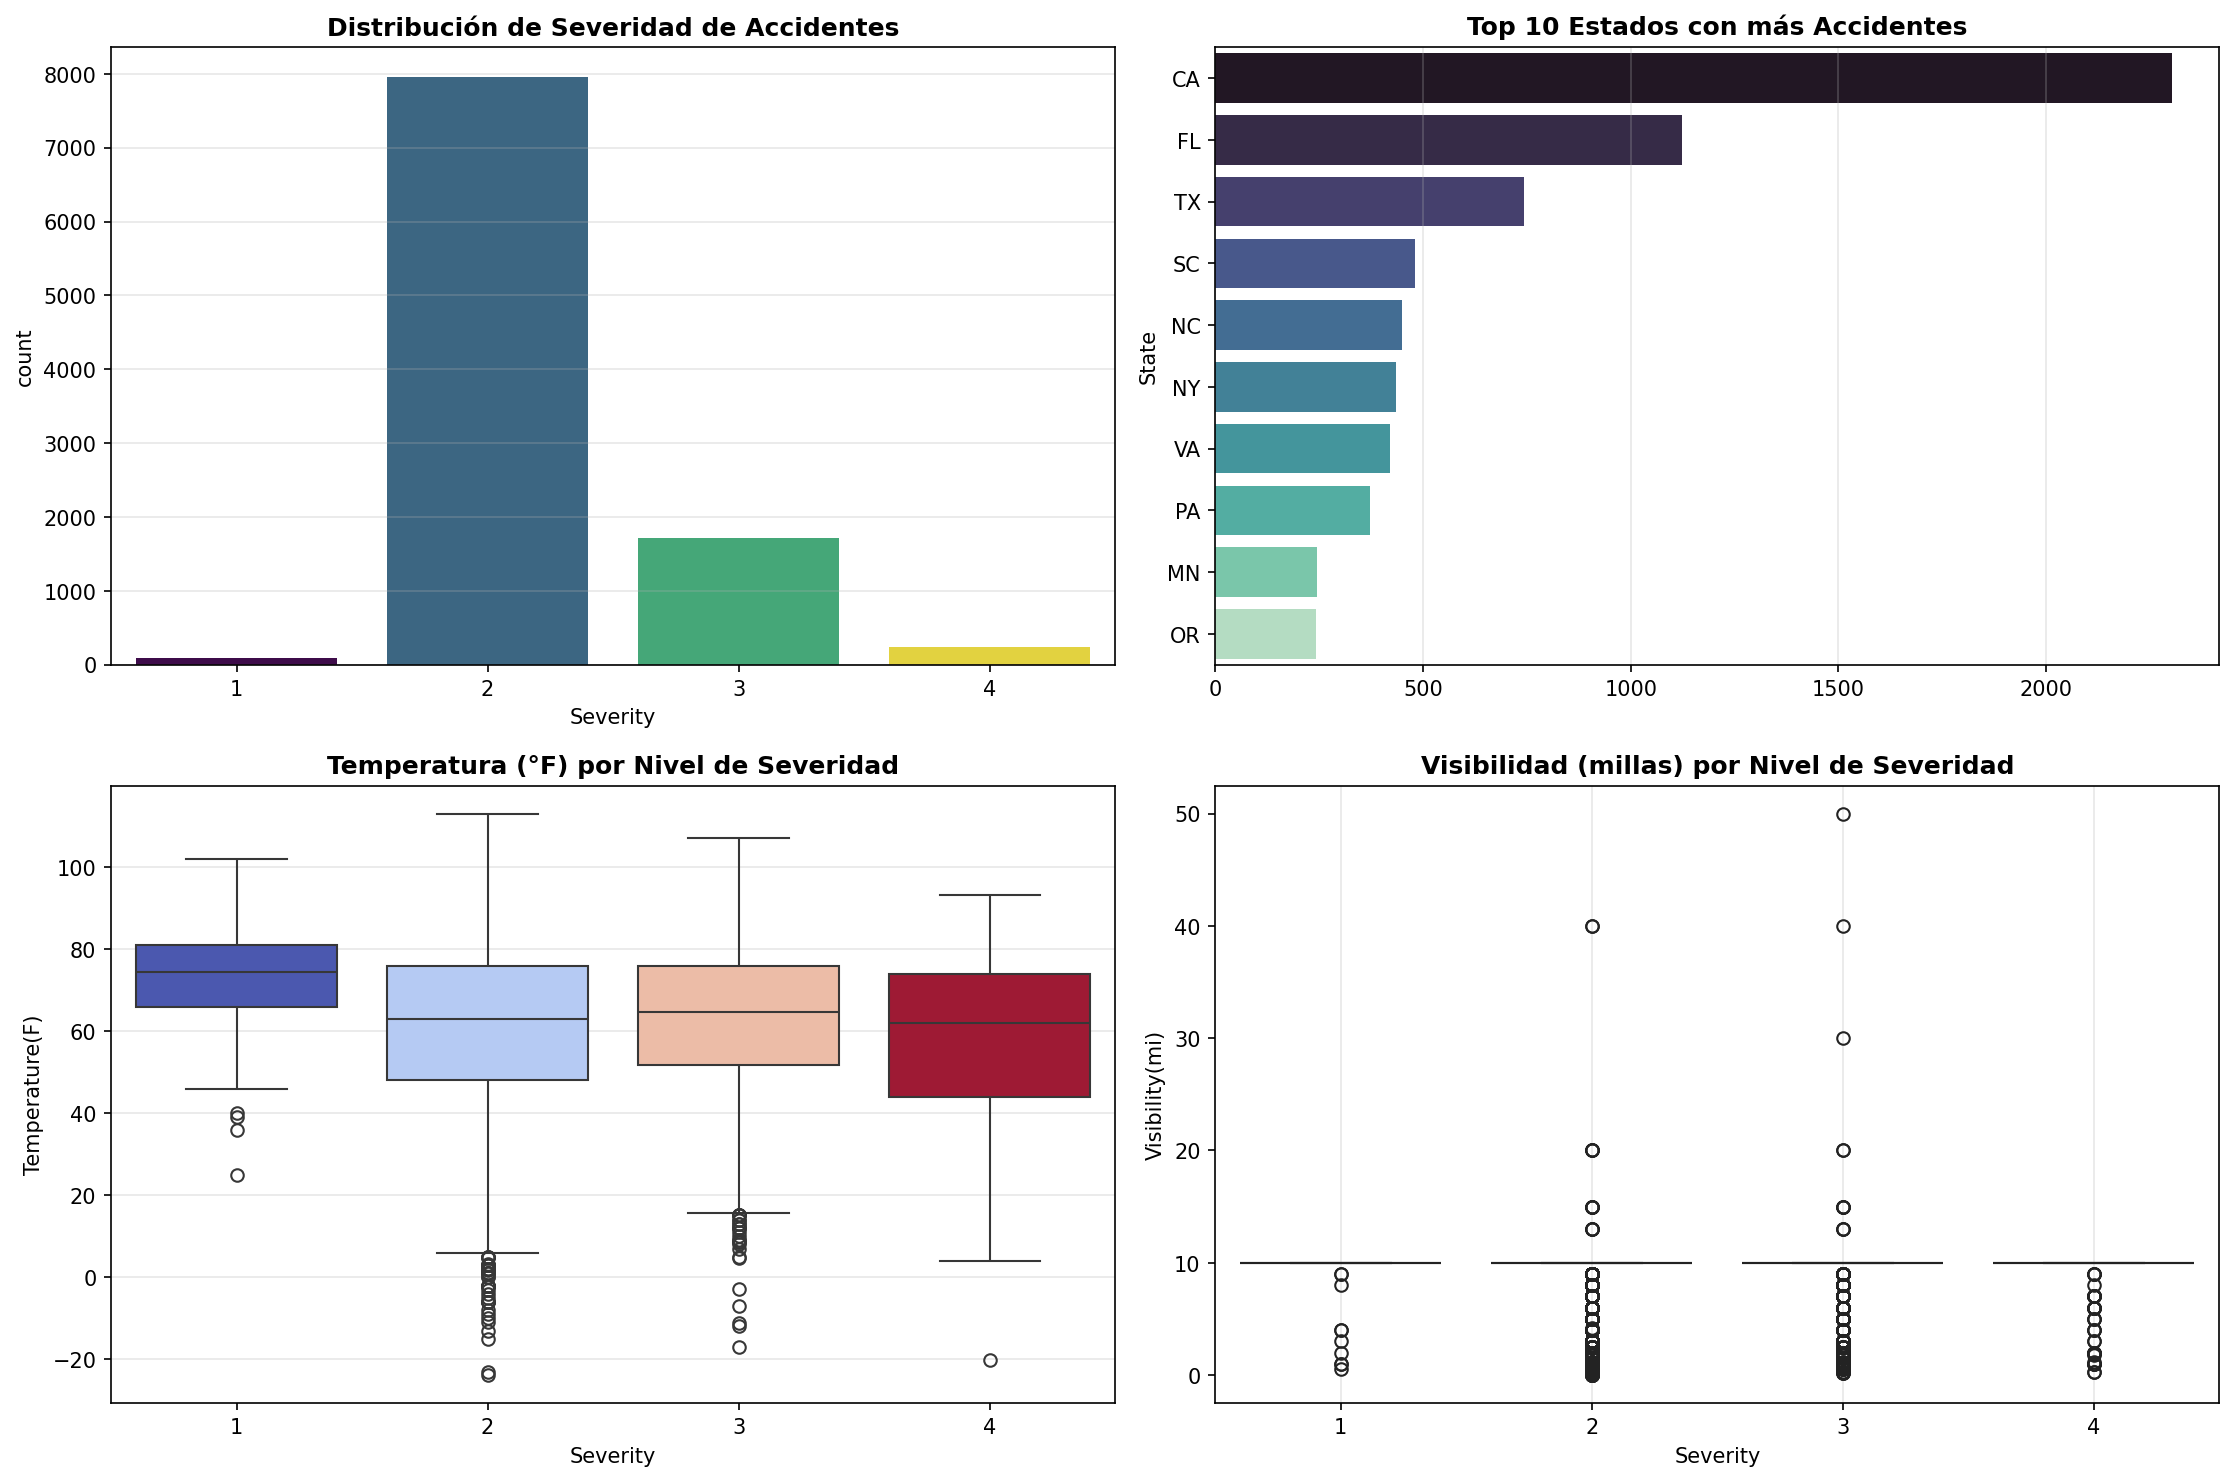

In [15]:
# 15. Visualizaciones Exploratorias y Estadísticas
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Muestra representativa de 10,000 registros para renderizado instantáneo y eficiente
cols_viz = ['Severity', 'State', 'Temperature(F)', 'Visibility(mi)']
df_sample = pd.read_parquet(parquet_path, columns=cols_viz).sample(n=min(10000, 7700000), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribución de Severidad
sns.countplot(data=df_sample, x='Severity', ax=axes[0, 0], hue='Severity', palette='viridis', legend=False)
axes[0, 0].set_title('Distribución de Severidad de Accidentes', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Accidentes por Estado (Top 10)
top_states = df_sample['State'].value_counts().head(10)
sns.barplot(x=top_states.values, y=top_states.index, ax=axes[0, 1], hue=top_states.index, palette='mako', legend=False)
axes[0, 1].set_title('Top 10 Estados con más Accidentes', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Temperatura vs Severidad
sns.boxplot(data=df_sample, x='Severity', y='Temperature(F)', ax=axes[1, 0], hue='Severity', palette='coolwarm', legend=False)
axes[1, 0].set_title('Temperatura (°F) por Nivel de Severidad', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Visibilidad vs Severidad
sns.boxplot(data=df_sample, x='Severity', y='Visibility(mi)', ax=axes[1, 1], hue='Severity', palette='Blues', legend=False)
axes[1, 1].set_title('Visibilidad (millas) por Nivel de Severidad', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
try:
    plt.show()
except Exception:
    plt.savefig('data/eda_visualizaciones.png')
    print('[OK] Gráficos guardados en data/eda_visualizaciones.png')


## Conclusiones y Resumen de la Arquitectura

1. **Indexación y Compresión Parquet:** Al aplicar compresión ZSTD e indexación física en bloques ordenados espacialmente (`Start_Lat`, `Start_Lng`), el dataset se redujo de 2.85 GB a menos de 500 MB (~83% de ahorro de almacenamiento y I/O), permitiendo a Parquet ignorar *row groups* irrelevantes mediante *predicate pushdown*.
2. **Comparativa Pandas vs PySpark:** En entornos mononodo con proyecciones de pocas columnas, Pandas vectorizado supera a Spark debido al overhead de inicialización de la JVM y serialización Py4J. No obstante, PySpark demuestra su superioridad en escalabilidad distribuida horizontal (out-of-core) en operaciones con memoria restringida y agregaciones con Window functions.
3. **Machine Learning Distribuido:** El pipeline de Spark MLlib (`VectorAssembler` + `OneHotEncoder` + `DecisionTreeClassifier`) clasifica la severidad vial alcanzando casi un 80% de Accuracy y F1 ponderado de 0.71, entrenado sobre millones de eventos viales de manera reproducible.